In [1]:
print("Hello World")

Hello World


In [2]:
# import all the requirment
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# define State /////in state class you will assign all the variable with there datatypes
class BMIState(TypedDict) :
    weight_kg: float
    height_kg: float
    bmi: float
    # extending our code to find if the person is fit or not
    category : str

In [4]:
#define graph //// like how we define an algorithm
graph = StateGraph(BMIState)

In [5]:
# define a functionn

def calculate_bmis (state : BMIState) -> BMIState:
    weight = state ['weight_kg']
    height = state ['height_kg']

# bmi formula 
    bmi = weight/(height**2)

#rounding off to the 2 decimal places 
    state['bmi']= round(bmi,2)

    return state


In [6]:
def label_input (state : BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5 :
        state['category'] = "underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "OverWeight"
    else:
        state['category'] = "obese"

    return state

In [7]:
# add nodes to the graph
graph.add_node('calculate_bmi',calculate_bmis)
graph.add_node('label_input', label_input)

# add edges to the graph 
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_input')
graph.add_edge('label_input',END)

#compile the graph ///// Graph can be complied only once 
workflow = graph.compile()


In [8]:
# execute the graph or invoke the graph
intital_state = {'weight_kg':80 , 'height_kg': 1.73}
final_state = workflow.invoke(intital_state)
print(final_state)

{'weight_kg': 80, 'height_kg': 1.73, 'bmi': 26.73, 'category': 'OverWeight'}


In [9]:
from IPython.display import Image

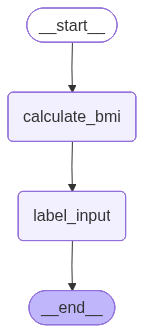

In [10]:
Image(workflow.get_graph().draw_mermaid_png())